In [1]:
import numpy as np
import pandas as pd

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)


# Jupyter visualization settings
%config InlineBackend.figure_format = 'retina'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

In [2]:
# 加载Titanic数据
file = '../../data/Titanic/titanic.csv'
df = pd.read_csv(file)
df = df.loc[:, ['Survived', 'Pclass', 'Sex']]
df.head()

,Survived,Pclass,Sex
0,0,3,male
1,1,1,female
2,1,3,female
3,1,1,female
4,0,3,male


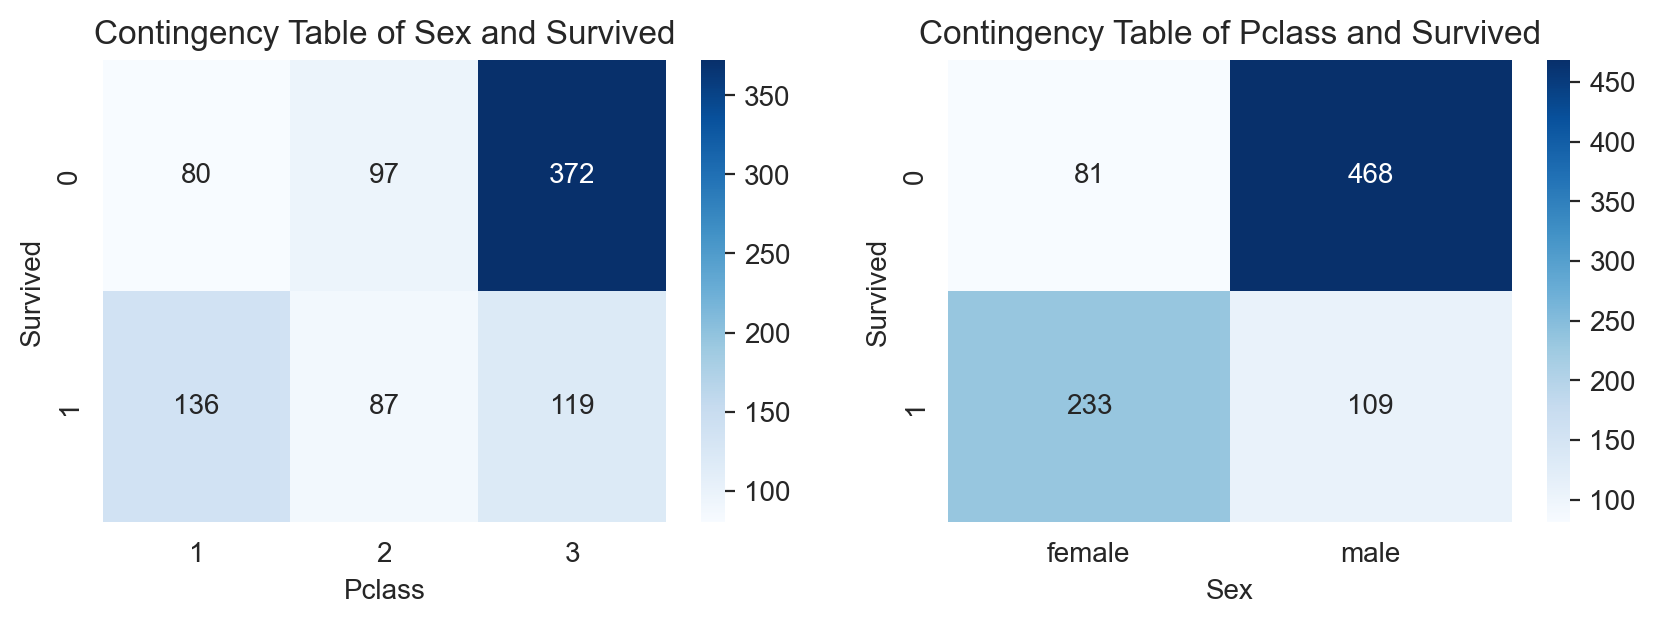

In [3]:
# 频数统计热力图（Survived-Pclass, Survived-Sex）
plt.figure(figsize = (10,3))
plt.subplot(121)
table_pclass = pd.crosstab(df['Survived'], df['Pclass'])
sns.heatmap(table_pclass, annot=True, fmt='d', cmap='Blues')
plt.title('Contingency Table of Sex and Survived')
plt.xlabel('Pclass')
plt.ylabel('Survived')
plt.subplot(122)
table_sex = pd.crosstab(df['Survived'], df['Sex'])
sns.heatmap(table_sex, annot=True, fmt='d', cmap='Blues')
plt.title('Contingency Table of Pclass and Survived')
plt.xlabel('Sex')
plt.ylabel('Survived')
plt.show()

In [4]:
# 卡方独立性检验（Survived-Pclass）
def chi2_independence(table):
    chi2, p, dof, ex = stats.chi2_contingency(table)
    return chi2, p, dof, ex

chi2_pclass, p_pclass, dof_pclass, ex_pclass = chi2_independence(table_pclass)
chi2_sex, p_sex, dof_sex, ex_sex = chi2_independence(table_sex)
print(f"Chi-square Test between Survived and Pclass:")
print(f"Chi2 Statistic: {chi2_pclass:.4f}, p-value: {p_pclass:.4f}, dof: {dof_pclass}")
if p_pclass < 0.05:
    print("拒绝原假设: Pclass和Survived不独立。")
else:
    print("不拒绝原假设: Pclass和Survived独立。")
print()
print(f"Chi-square Test between Survived and Sex:")
print(f"Chi2 Statistic: {chi2_sex:.4f}, p-value: {p_sex:.4f}, dof: {dof_sex}")
if p_sex < 0.05:
    print("拒绝原假设: Sex和Survived不独立。")
else:
    print("不拒绝原假设: Sex和Survived独立。")

Chi-square Test between Survived and Pclass:
Chi2 Statistic: 102.8890, p-value: 0.0000, dof: 2
拒绝原假设: Pclass和Survived不独立。

Chi-square Test between Survived and Sex:
Chi2 Statistic: 260.7170, p-value: 0.0000, dof: 1
拒绝原假设: Sex和Survived不独立。
